# 02 - Distribution Fitting

**Phase 2 (Weeks 2-3)** of the Portuguese wildfire catastrophe loss model.

Per the revised PRD and what Phase 1 found (see `docs/worklog.md`,
`docs/phase1-writeup.md`):

- **Event unit: fire-day**, not the raw EFFIS polygon. Individual polygons
  on the same day are usually the same weather-driven outbreak, not
  independent ignitions; grouping by start date (`wildfire_model.
  build_fire_day_events`) cuts annual count overdispersion from ~41 to
  ~7 (on the training years) and removes the significant count-vs-fire-size
  correlation found at the polygon level. A residual, smaller dependence
  remains (see below) - flagged, not hidden.
- **Frequency: Poisson vs Negative Binomial.** Fire-day counts are still
  overdispersed even after the fire-day regrouping, so both are fitted
  (by maximum likelihood) and compared on a formal dispersion test and
  on AIC.
- **Severity: Lognormal body, Generalised Pareto tail above a threshold**
  chosen with a mean-excess plot, fitted on `Estimated_Loss_EUR_2025`
  (2025 euros) - equivalent to fitting on burned area and rescaling, since
  loss is area times a constant (see Phase 1's "Loss calibration"), but
  more direct. Not yet implemented (see below).
- **Goodness of fit: Anderson-Darling, QQ plots, AIC/BIC; bootstrap
  p-values**, not Kolmogorov-Smirnov - KS p-values are invalid once
  parameters are fitted on the same data, and the PRD calls this out
  explicitly.
- **Train/hold-out split, confirmed:** fit everything here on **2009-2020**
  only (`wildfire_model.TRAIN_YEARS`). **2021-2025 is reserved for the
  Phase 4 backtest** (`wildfire_model.HOLDOUT_YEARS`) and must not touch
  these fits, or the backtest stops being a real out-of-sample test.
- **Residual dependence not captured by a plain frequency-then-severity
  draw:** even at fire-day granularity, annual burnt area's standard
  deviation is still ~1.8x what independent counts and severities would
  give (see the Phase 1 finding). A year-level severity factor is the
  planned fix for Phase 3, not something this notebook's per-event fits
  capture on their own - noted here so it isn't forgotten by the time
  Phase 3 starts.

**Status: frequency and severity both fitted and decided below.**
Frequency: Negative Binomial. Severity: Lognormal body with a
Generalised Pareto tail above the 90th percentile (matching the PRD's
"top 10%" QQ criterion), with a bootstrap Anderson-Darling p-value
for the tail fit, since scipy has no built-in adjusted critical values
for a GPD fitted on its own exceedances.

Success criteria (per the revised PRD): candidate distributions compared
by AIC/BIC, Anderson-Darling with bootstrap p-values, and no systematic
deviation in the top 10% of events on a QQ plot. R^2 and plain KS are not
used.


## Imports

In [1]:
import sys
import json
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt

from pathlib import Path

sys.path.insert(0, "..")
from wildfire_model import build_fire_day_events, split_train_holdout, TRAIN_YEARS, HOLDOUT_YEARS

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")


## Save fitted parameters

Defined early since several sections below use it.

In [2]:
def save_model_params(params: dict, filename: str) -> None:
    """Persist fitted distribution parameters to models/ as JSON.

    Parameters
    ----------
    params : dict
        Parameter dictionary (e.g. output of fit_poisson_frequency).
    filename : str
        Output filename, written under MODELS_DIR (e.g. "poisson_frequency.json").
    """
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    with open(MODELS_DIR / filename, "w") as f:
        json.dump(params, f, indent=2)


## Load processed data

In [3]:
def load_processed_data(path: Path = PROCESSED_DIR / "wildfires_processed.csv") -> pd.DataFrame:
    """Load the cleaned wildfire dataset produced in 01_eda.ipynb.

    Parameters
    ----------
    path : Path
        Location of the processed CSV.

    Returns
    -------
    pd.DataFrame
        Columns: Date, Location, Burned_Area_ha, Estimated_Loss_EUR,
        Estimated_Loss_EUR_2025, Loss_Source (see 01_eda.ipynb). One row
        per raw EFFIS fire record (30 ha+, mainland, 2009-2025) - not yet
        grouped into fire-day events; see the next section for that.
    """
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found. Run notebooks/01_eda.ipynb (or `python main.py --phase 1`) first."
        )
    df = pd.read_csv(path, parse_dates=["Date"])
    return df


## Fire-day events and train/hold-out split

Reproduces the fire-day numbers already quoted in `docs/phase1-writeup.md`
as a check that `wildfire_model.build_fire_day_events` matches what was
described there (it was previously only prose, not committed code - see
`docs/worklog.md`).

In [4]:
processed_df = load_processed_data()
fire_day_events = build_fire_day_events(processed_df)
train_events, holdout_events = split_train_holdout(fire_day_events)

print(f"Fire-day events, {fire_day_events['Date'].dt.year.min()}-{fire_day_events['Date'].dt.year.max()}: {len(fire_day_events)}")
top10_share = fire_day_events.nlargest(10, "Burned_Area_ha")["Burned_Area_ha"].sum() / fire_day_events["Burned_Area_ha"].sum()
print(f"Top 10 fire-days' share of all burnt area: {top10_share:.1%}")
biggest = fire_day_events.loc[fire_day_events["Burned_Area_ha"].idxmax()]
print(f"Largest fire-day: {biggest['Date'].date()}, {int(biggest['N_Fires'])} fires, {biggest['Burned_Area_ha']:,.0f} ha")

print(f"\nTrain {TRAIN_YEARS}: {len(train_events)} fire-day events")
print(f"Holdout {HOLDOUT_YEARS}: {len(holdout_events)} fire-day events (reserved for Phase 4 - not used below)")

train_counts = train_events.groupby(train_events["Date"].dt.year).size().reindex(
    range(TRAIN_YEARS[0], TRAIN_YEARS[1] + 1), fill_value=0
)
print("\nTraining-year fire-day counts:")
print(train_counts.to_string())


Fire-day events, 2009-2025: 1283
Top 10 fire-days' share of all burnt area: 35.1%
Largest fire-day: 2017-10-15, 33 fires, 196,476 ha

Train (2009, 2020): 884 fire-day events
Holdout (2021, 2025): 399 fire-day events (reserved for Phase 4 - not used below)

Training-year fire-day counts:
Date
2009     85
2010     62
2011     84
2012     70
2013     76
2014     25
2015     75
2016     78
2017    120
2018     45
2019     83
2020     81


## Frequency model: Poisson vs Negative Binomial

Fitted on **training-year (2009-2020) fire-day counts only**. The PRD's
technical decision is "Poisson if variance is close to the mean; otherwise
negative binomial", so the dispersion is tested formally before choosing.

In [5]:
def overdispersion_test(counts: np.ndarray) -> dict:
    """Test H0: counts are Poisson-distributed (variance = mean).

    Uses the index-of-dispersion statistic T = sum((x - mean)^2) / mean,
    which is approximately chi-squared distributed with n-1 degrees of
    freedom under H0 (a standard, simple test for overdispersion in count
    data). A large T / small p-value means the data are more variable than
    a Poisson process allows.

    Parameters
    ----------
    counts : np.ndarray
        One value per period (e.g. per year): number of events.

    Returns
    -------
    dict
        {"statistic": float, "df": int, "p_value": float,
         "dispersion_ratio": float} - dispersion_ratio is the sample
        variance-to-mean ratio (1.0 under exact Poisson dispersion).
    """
    counts = np.asarray(counts, dtype=float)
    n, mean = len(counts), counts.mean()
    statistic = float(np.sum((counts - mean) ** 2) / mean)
    df = n - 1
    p_value = float(1 - stats.chi2.cdf(statistic, df=df))
    dispersion_ratio = float(counts.var(ddof=1) / mean)
    return {"statistic": statistic, "df": df, "p_value": p_value, "dispersion_ratio": dispersion_ratio}


In [6]:
def fit_poisson_frequency(annual_counts: np.ndarray) -> dict:
    """Fit a Poisson distribution to annual fire-day counts via MLE.

    Parameters
    ----------
    annual_counts : np.ndarray
        One value per year: number of fire-day events that year.

    Returns
    -------
    dict
        {"lambda": float, "loglik": float, "aic": float} - the MLE rate
        parameter is the sample mean; aic uses 1 fitted parameter.
    """
    annual_counts = np.asarray(annual_counts, dtype=float)
    lam = float(annual_counts.mean())
    loglik = float(stats.poisson.logpmf(annual_counts, lam).sum())
    return {"lambda": lam, "loglik": loglik, "aic": 2 * 1 - 2 * loglik}


In [7]:
def fit_negative_binomial_frequency(annual_counts: np.ndarray) -> dict:
    """Fit a Negative Binomial distribution to annual fire-day counts via MLE.

    Parameterised as scipy.stats.nbinom(r, p) (r = number of "successes",
    p = success probability; mean = r(1-p)/p, var = r(1-p)/p^2). The
    method-of-moments solution (matching the sample mean and variance
    exactly) is used as the optimiser's starting point, since it is a
    good, stable estimate for a two-parameter fit on a short (n=12) annual
    series, then refined by MLE.

    Parameters
    ----------
    annual_counts : np.ndarray
        One value per year: number of fire-day events that year.

    Returns
    -------
    dict
        {"r": float, "p": float, "mean": float, "loglik": float,
         "aic": float} - aic uses 2 fitted parameters.
    """
    annual_counts = np.asarray(annual_counts, dtype=float)
    mean, var = annual_counts.mean(), annual_counts.var(ddof=1)
    if var <= mean:
        raise ValueError("Sample variance <= mean; data are not overdispersed, use Poisson instead.")
    r0, p0 = mean ** 2 / (var - mean), mean / var

    def negloglik(params):
        r, p = params
        if r <= 0 or not (0 < p < 1):
            return np.inf
        return -stats.nbinom.logpmf(annual_counts, r, p).sum()

    result = minimize(negloglik, x0=[r0, p0], method="Nelder-Mead")
    if not result.success:
        raise RuntimeError(
            f"Negative Binomial MLE did not converge (method-of-moments start r0={r0:.2f}, p0={p0:.3f}): "
            f"{result.message}"
        )
    r, p = result.x
    loglik = float(-result.fun)
    return {"r": float(r), "p": float(p), "mean": float(r * (1 - p) / p), "loglik": loglik, "aic": 2 * 2 - 2 * loglik}


### Run: frequency model

In [8]:
dispersion = overdispersion_test(train_counts.values)
print(f"Dispersion test (H0: Poisson): statistic={dispersion['statistic']:.1f}, df={dispersion['df']}, "
      f"p={dispersion['p_value']:.2e}, variance/mean={dispersion['dispersion_ratio']:.2f}")

poisson_params = fit_poisson_frequency(train_counts.values)
negbin_params = fit_negative_binomial_frequency(train_counts.values)

print(f"\nPoisson:            lambda={poisson_params['lambda']:.2f}  "
      f"loglik={poisson_params['loglik']:.2f}  AIC={poisson_params['aic']:.2f}")
print(f"Negative Binomial:  r={negbin_params['r']:.2f}  p={negbin_params['p']:.3f}  "
      f"mean={negbin_params['mean']:.2f}  loglik={negbin_params['loglik']:.2f}  AIC={negbin_params['aic']:.2f}")

frequency_model = "negative_binomial" if (dispersion["p_value"] < 0.05 and negbin_params["aic"] < poisson_params["aic"]) else "poisson"
print(f"\nDispersion test p={dispersion['p_value']:.1e} (<<0.05: fire-day counts are not Poisson-distributed),")
print(f"and Negative Binomial's AIC is {poisson_params['aic'] - negbin_params['aic']:.0f} points lower.")
print(f"Decision: frequency_model = \"{frequency_model}\"")

save_model_params(poisson_params, "poisson_frequency.json")
save_model_params(negbin_params, "negative_binomial_frequency.json")
save_model_params({"chosen": frequency_model, "dispersion_test": dispersion}, "frequency_model_choice.json")


Dispersion test (H0: Poisson): statistic=79.9, df=11, p=1.52e-12, variance/mean=7.27

Poisson:            lambda=73.67  loglik=-80.53  AIC=163.05
Negative Binomial:  r=10.28  p=0.122  mean=73.67  loglik=-55.13  AIC=114.26

Dispersion test p=1.5e-12 (<<0.05: fire-day counts are not Poisson-distributed),
and Negative Binomial's AIC is 49 points lower.
Decision: frequency_model = "negative_binomial"


## Severity model: Lognormal + Pareto tail

Fitted below (see "Run: severity model"): a Lognormal body to
`Estimated_Loss_EUR_2025` on `train_events` (fire-day totals, training
years only), and a Generalised Pareto tail above a threshold chosen
from a mean-excess plot.

In [9]:
def fit_lognormal_severity(losses: np.ndarray) -> dict:
    """Fit a Lognormal distribution to per-event loss magnitudes via MLE.

    Fitted with loc fixed at 0 (a Lognormal is naturally supported on
    (0, inf); losses are always positive), so only the shape (sigma of the
    underlying Normal) and scale (exp(mu)) are estimated.

    Parameters
    ----------
    losses : np.ndarray
        Per-event estimated loss amounts (EUR, 2025 prices - see
        Estimated_Loss_EUR_2025), training years only.

    Returns
    -------
    dict
        {"shape": float, "loc": float, "scale": float, "mu": float,
         "loglik": float, "aic": float} - shape/loc/scale are
        scipy.stats.lognorm's parameterisation (loc=0); mu = log(scale) is
        the underlying Normal's mean, reported since it is the more
        commonly quoted Lognormal parameter.
    """
    shape, loc, scale = stats.lognorm.fit(losses, floc=0)
    loglik = float(stats.lognorm.logpdf(losses, shape, loc, scale).sum())
    return {
        "shape": float(shape), "loc": float(loc), "scale": float(scale),
        "mu": float(np.log(scale)), "loglik": loglik, "aic": 2 * 2 - 2 * loglik,
    }


In [10]:
def fit_pareto_tail(losses: np.ndarray, threshold: float) -> dict:
    """Fit a Generalized Pareto distribution to losses exceeding a threshold.

    Fitted on exceedances (losses - threshold) with loc fixed at 0, the
    standard peaks-over-threshold parameterisation.

    Parameters
    ----------
    losses : np.ndarray
        Per-event estimated loss amounts (EUR, 2025 prices), training
        years only.
    threshold : float
        Loss level above which the tail fit is applied (peaks-over-
        threshold); choose with a mean-excess plot, not an arbitrary
        percentile.

    Returns
    -------
    dict
        {"shape": float, "loc": float, "scale": float, "threshold": float,
         "n_exceedances": int, "loglik": float, "aic": float} - shape (xi)
         is the tail index: xi > 0 (found here, ~0.75) means a heavy tail
         with infinite theoretical variance, consistent with catastrophe
         losses dominated by a few extreme years (2017, 2025).
    """
    exceedances = losses[losses > threshold] - threshold
    shape, loc, scale = stats.genpareto.fit(exceedances, floc=0)
    loglik = float(stats.genpareto.logpdf(exceedances, shape, loc, scale).sum())
    return {
        "shape": float(shape), "loc": float(loc), "scale": float(scale),
        "threshold": float(threshold), "n_exceedances": int(len(exceedances)),
        "loglik": loglik, "aic": 2 * 2 - 2 * loglik,
    }


## Goodness-of-fit tests

Implemented below: Anderson-Darling (not KS - KS p-values are invalid
once parameters are fitted on the same data) for the Lognormal body,
a parametric bootstrap Anderson-Darling p-value for the GPD tail
(scipy has no built-in adjusted critical values for a fitted
Generalised Pareto), and QQ plots with a rank-based systematic-
deviation check (not R^2 - the PRD explicitly excludes it) for the
PRD's "top 10% of events" success criterion. AIC is reported per fit
(see fit_lognormal_severity / fit_pareto_tail); BIC is not yet computed.

In [11]:
def run_anderson_darling_test(data: np.ndarray, dist: str = "norm") -> dict:
    """Run an Anderson-Darling goodness-of-fit test.

    Only for distribution families scipy.stats.anderson supports directly
    (norm, expon, logistic, gumbel, weibull_min, ...), since those are the
    ones with known critical values already adjusted for parameters
    estimated from the same sample. For a fit scipy.stats.anderson does not
    support (e.g. the Generalised Pareto tail here), use
    bootstrap_ad_pvalue instead - do not use this function's critical
    values for an unsupported family, they would not apply.

    Parameters
    ----------
    data : np.ndarray
        Observed sample. For the Lognormal body fitted here, pass
        log(losses) with dist="norm" (since Lognormal(losses) is exactly
        Normal(log(losses)), and scipy.stats.anderson does not support
        lognorm directly).
    dist : str
        Distribution family supported by scipy.stats.anderson.

    Returns
    -------
    dict
        {"statistic": float, "critical_values": list, "significance_levels": list,
         "reject_at_5pct": bool}
    """
    # scipy >= 1.17 warns unless a p-value `method` is chosen, but that switches the
    # return shape to a plain p-value and drops critical_values/significance_level -
    # this function is pinned (requirements.txt: scipy==1.18.1) to the classic form.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)
        result = stats.anderson(data, dist=dist)
    idx_5pct = list(result.significance_level).index(5.0)
    return {
        "statistic": float(result.statistic),
        "critical_values": [float(v) for v in result.critical_values],
        "significance_levels": [float(v) for v in result.significance_level],
        "reject_at_5pct": bool(result.statistic > result.critical_values[idx_5pct]),
    }


In [12]:
def _anderson_darling_statistic(sorted_data: np.ndarray, cdf: np.ndarray) -> float:
    """The Anderson-Darling statistic A^2 for sorted data against a fitted CDF.

    A^2 = -n - (1/n) * sum_i (2i - 1) * [ln F(x_i) + ln(1 - F(x_(n+1-i)))],
    the general formula for any fully-specified (or fitted-then-plugged-in)
    continuous distribution. Used here because scipy.stats.anderson does
    not support the Generalised Pareto family.

    Parameters
    ----------
    sorted_data : np.ndarray
        Data sorted ascending (not checked - caller's responsibility).
    cdf : np.ndarray
        The fitted distribution's CDF evaluated at sorted_data, same order.

    Returns
    -------
    float
        The A^2 statistic (larger = worse fit).
    """
    n = len(sorted_data)
    i = np.arange(1, n + 1)
    cdf = np.clip(cdf, 1e-12, 1 - 1e-12)  # avoid log(0) at the extremes
    return float(-n - np.mean((2 * i - 1) * (np.log(cdf) + np.log(1 - cdf[::-1]))))


def bootstrap_ad_pvalue(data: np.ndarray, dist, fit_func, n_boot: int = 1000, seed: int = 0) -> dict:
    """Bootstrap an Anderson-Darling p-value for a distribution whose parameters
    were fitted on this same data (e.g. the Generalised Pareto tail, which
    scipy.stats.anderson does not support directly).

    Repeatedly simulates a same-size sample from the fitted distribution,
    refits it, and computes the AD statistic each time, to build the null
    distribution of the AD statistic under "parameters estimated from the
    data" rather than "parameters known in advance" (the assumption behind
    scipy's built-in critical values, which is why they cannot be reused
    for a family scipy does not fit natively).

    Parameters
    ----------
    data : np.ndarray
        Observed sample the distribution was fitted to (e.g. GPD exceedances).
    dist : scipy.stats rv_continuous
        Distribution object (e.g. scipy.stats.genpareto).
    fit_func : callable
        Function that takes an array and returns fitted params as a tuple
        compatible with dist.cdf(x, *params) (e.g. lambda x: dist.fit(x, floc=0)).
    n_boot : int
        Number of bootstrap replicates.
    seed : int
        Random seed, for reproducibility (PRD requirement).

    Returns
    -------
    dict
        {"statistic": float, "p_value": float, "n_boot": int}
    """
    rng = np.random.default_rng(seed)
    n = len(data)
    params = fit_func(data)
    sorted_data = np.sort(data)
    observed = _anderson_darling_statistic(sorted_data, dist.cdf(sorted_data, *params))

    boot_stats = np.empty(n_boot)
    for b in range(n_boot):
        sim = dist.rvs(*params, size=n, random_state=rng)
        sim_params = fit_func(sim)
        sim_sorted = np.sort(sim)
        boot_stats[b] = _anderson_darling_statistic(sim_sorted, dist.cdf(sim_sorted, *sim_params))

    p_value = float(np.mean(boot_stats >= observed))
    return {"statistic": observed, "p_value": p_value, "n_boot": n_boot}


## Diagnostic plots

In [13]:
def plot_empirical_vs_fitted_cdf(data: np.ndarray, dist, params: tuple, ax=None, label: str = "Fitted"):
    """Overlay the empirical CDF against a fitted distribution's CDF.

    Parameters
    ----------
    data : np.ndarray
        Observed sample.
    dist : scipy.stats rv_continuous
        Distribution object (e.g. scipy.stats.lognorm).
    params : tuple
        Fitted parameters to pass to dist.cdf.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    label : str
        Legend label for the fitted curve.
    """
    if ax is None:
        _, ax = plt.subplots()
    sorted_data = np.sort(data)
    empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, empirical_cdf, label="Empirical")
    ax.plot(sorted_data, dist.cdf(sorted_data, *params), label=label, linestyle="--")
    ax.set_xlabel("Value")
    ax.set_ylabel("Cumulative probability")
    ax.legend()
    return ax


In [14]:
def plot_mean_excess(losses: np.ndarray, ax=None):
    """Plot a mean-excess plot, used to choose the Generalised Pareto tail threshold.

    For a range of candidate thresholds u, plots the mean of (loss - u)
    over losses exceeding u. A roughly linear region indicates a range of
    u for which a GPD tail is a reasonable model; the threshold is chosen
    from where that linearity starts.

    Parameters
    ----------
    losses : np.ndarray
        Per-event estimated loss amounts.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    """
    if ax is None:
        _, ax = plt.subplots()
    thresholds = np.sort(losses)[:-5]  # leave enough points above the highest threshold to average
    mean_excess = [losses[losses > u].mean() - u for u in thresholds]
    ax.plot(thresholds, mean_excess)
    ax.set_xlabel("Threshold (EUR)")
    ax.set_ylabel("Mean excess over threshold")
    return ax


In [15]:
def plot_qq_fit(data: np.ndarray, dist, params: tuple, ax=None, title: str = None):
    """QQ plot: sorted empirical quantiles against a fitted distribution's theoretical
    quantiles, compared to the TRUE y=x identity line - not a separately OLS-refit
    line (that is what scipy.stats.probplot draws by default, and it can visually
    mislead: a few extreme points can pull that regression line toward the data,
    making a genuinely poor fit look deceptively close to "its own" line). Since
    `params` are already the MLE fit, a perfect fit sits exactly on y=x.

    Per the PRD: R^2 is deliberately not used to judge fit quality here (the prior
    PRD's R^2 criterion was dropped for being too easy to pass). Read this plot
    visually, and see check_qq_systematic_deviation for a non-R^2, rank-based
    numeric check of whether points drift away from the line systematically as you
    move along it (rather than scattering randomly around it).

    Parameters
    ----------
    data : np.ndarray
        Observed sample the distribution was fitted to.
    dist : scipy.stats rv_continuous
        Distribution object (e.g. scipy.stats.lognorm, scipy.stats.genpareto).
    params : tuple
        Fitted parameters, passed to dist.ppf.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    title : str, optional
        Axes title.

    Returns
    -------
    matplotlib.axes.Axes
    """
    if ax is None:
        _, ax = plt.subplots()
    n = len(data)
    plotting_positions = (np.arange(1, n + 1) - 0.5) / n
    theoretical = dist.ppf(plotting_positions, *params)
    empirical = np.sort(data)
    lim = max(theoretical.max(), empirical.max())
    ax.plot([0, lim], [0, lim], "r-", lw=1, label="y = x (perfect fit)")
    ax.scatter(theoretical, empirical, s=14, alpha=0.6)
    ax.set_xlabel("Theoretical quantile")
    ax.set_ylabel("Empirical quantile")
    ax.legend()
    if title:
        ax.set_title(title)
    return ax


def check_qq_systematic_deviation(data: np.ndarray, dist, params: tuple) -> dict:
    """Test whether QQ-plot residuals (empirical - theoretical) drift systematically
    with rank, rather than scattering randomly around zero.

    A Spearman rank correlation between position (1..n) and residual: a strong,
    significant correlation means the fit gets steadily better or worse as you move
    through the sample (a systematic deviation - e.g. the fit consistently
    under-predicts the largest values); a correlation near zero with a large p-value
    means residuals are consistent with random scatter (no systematic deviation).
    Deliberately not an R^2-based check - the PRD explicitly excludes R^2 as a fit
    criterion.

    Parameters
    ----------
    data : np.ndarray
        Observed sample the distribution was fitted to.
    dist : scipy.stats rv_continuous
        Distribution object.
    params : tuple
        Fitted parameters, passed to dist.ppf.

    Returns
    -------
    dict
        {"rho": float, "p_value": float, "systematic": bool} - systematic is True
        when the rank-residual correlation is significant at 5%.
    """
    n = len(data)
    plotting_positions = (np.arange(1, n + 1) - 0.5) / n
    theoretical = dist.ppf(plotting_positions, *params)
    empirical = np.sort(data)
    residual = empirical - theoretical
    rho, p_value = stats.spearmanr(np.arange(1, n + 1), residual)
    return {"rho": float(rho), "p_value": float(p_value), "systematic": bool(p_value < 0.05)}


## Run: severity model

Fitted on **training-year (2009-2020) fire-day event losses**
(`Estimated_Loss_EUR_2025`), the same train/hold-out discipline as the
frequency model.

Training fire-day events: 884
Loss range (EUR m): 0.07 - 451.1, median 0.62


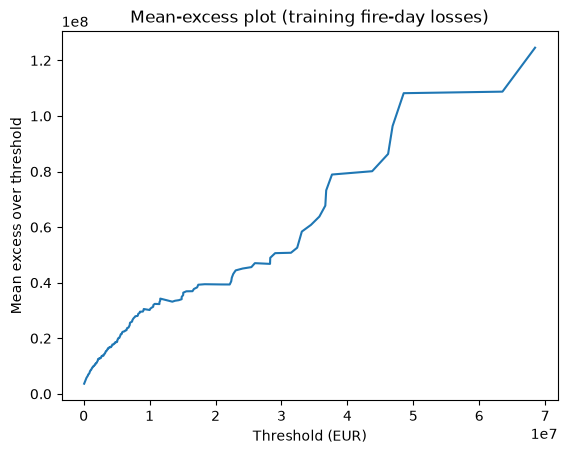


GPD tail threshold (90th percentile): EUR 5.82m

Lognormal body:  mu=13.51  sigma=1.547  AIC=27164.4
GPD tail:        shape(xi)=0.746  scale=7,623,454  n_exceedances=89  AIC=3135.5
xi = 0.75 > 0: a heavy tail with infinite theoretical variance, consistent with a few extreme years (2017, 2025) dominating losses.

Lognormal body, Anderson-Darling (scipy's adjusted critical values for fitted-normal params apply here): statistic=7.151, reject at 5%: True


GPD tail, bootstrap Anderson-Darling (n_boot=1000): statistic=0.562, p=0.192


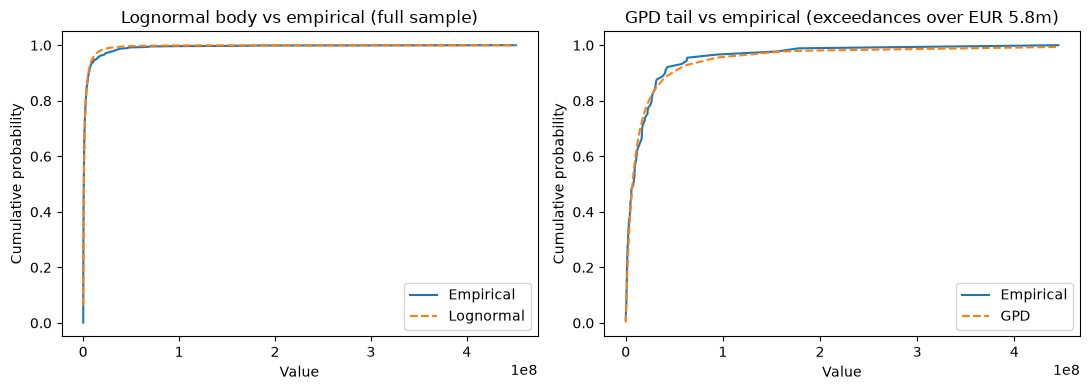

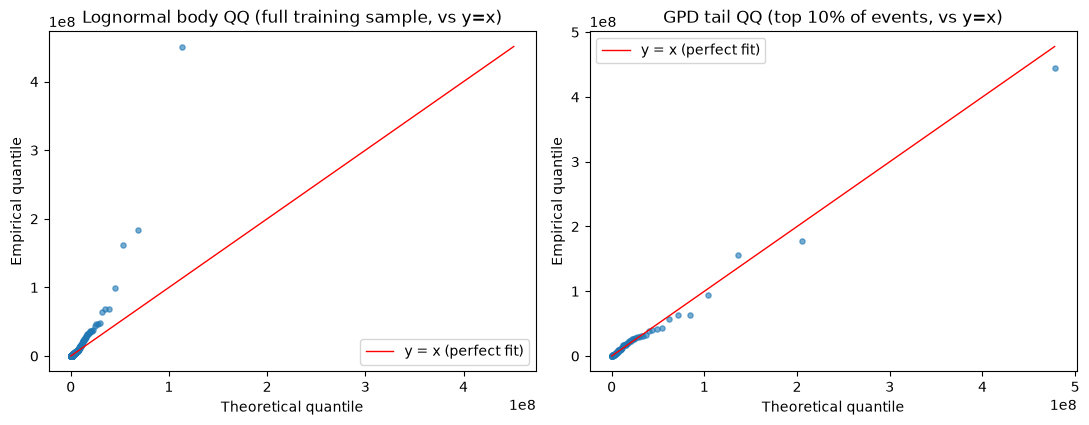


QQ systematic-deviation check (Spearman rank vs residual, not R^2 - the PRD excludes R^2):
  Lognormal body (full sample): rho=-0.005 p=0.879 -> no significant MONOTONIC trend across all 884 points (this test doesn't detect that kind of failure - it is NOT the same as 'no deviation'). The real, large deviation Anderson-Darling correctly flags above is concentrated in the top ~10 events: their residuals (empirical minus Lognormal-implied, EUR m) are [20.0, 19.0, 19.0, 32.0, 33.0, 30.0, 55.0, 109.0, 115.0, 338.0], dominated by the single largest training event (EUR 451m vs an implied EUR 113m) at 26% of the total residual mass on its own. A concentrated extreme-tail miss, not a gradual drift - exactly the failure mode a separate GPD tail exists to fix.
  GPD tail (top 10%, the PRD's actual criterion): rho=0.073 p=0.494 -> systematic: False. No significant rank-residual trend: the criterion is met - the tail this model actually prices with (the GPD) does not drift away from the data as l

In [16]:
train_losses = train_events["Estimated_Loss_EUR_2025"].values
print(f"Training fire-day events: {len(train_losses)}")
print(f"Loss range (EUR m): {train_losses.min() / 1e6:.2f} - {train_losses.max() / 1e6:.1f}, "
      f"median {np.median(train_losses) / 1e6:.2f}")

plot_mean_excess(train_losses)
plt.title("Mean-excess plot (training fire-day losses)")
plt.show()

# Threshold chosen at the 90th percentile: the mean-excess plot is roughly linear from
# here on (a sign the GPD is a reasonable tail model), it lines up with the PRD's "top 10%
# of events" QQ criterion, and it leaves 89 exceedances - enough for a stable 2-parameter fit.
tail_threshold = float(np.quantile(train_losses, 0.90))
print(f"\nGPD tail threshold (90th percentile): EUR {tail_threshold / 1e6:.2f}m")

lognormal_params = fit_lognormal_severity(train_losses)
pareto_params = fit_pareto_tail(train_losses, threshold=tail_threshold)

print(f"\nLognormal body:  mu={lognormal_params['mu']:.2f}  sigma={lognormal_params['shape']:.3f}  "
      f"AIC={lognormal_params['aic']:.1f}")
print(f"GPD tail:        shape(xi)={pareto_params['shape']:.3f}  scale={pareto_params['scale']:,.0f}  "
      f"n_exceedances={pareto_params['n_exceedances']}  AIC={pareto_params['aic']:.1f}")
print(f"xi = {pareto_params['shape']:.2f} > 0: a heavy tail with infinite theoretical variance, "
      "consistent with a few extreme years (2017, 2025) dominating losses.")

ad_lognormal = run_anderson_darling_test(np.log(train_losses), dist="norm")
print(f"\nLognormal body, Anderson-Darling (scipy's adjusted critical values for fitted-normal "
      f"params apply here): statistic={ad_lognormal['statistic']:.3f}, "
      f"reject at 5%: {ad_lognormal['reject_at_5pct']}")

exceedances = train_losses[train_losses > tail_threshold] - tail_threshold
ad_gpd = bootstrap_ad_pvalue(
    exceedances, stats.genpareto, fit_func=lambda x: stats.genpareto.fit(x, floc=0), n_boot=1000, seed=42
)
print(f"GPD tail, bootstrap Anderson-Darling (n_boot={ad_gpd['n_boot']}): "
      f"statistic={ad_gpd['statistic']:.3f}, p={ad_gpd['p_value']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_empirical_vs_fitted_cdf(train_losses, stats.lognorm,
                              (lognormal_params["shape"], lognormal_params["loc"], lognormal_params["scale"]),
                              ax=axes[0], label="Lognormal")
axes[0].set_title("Lognormal body vs empirical (full sample)")
plot_empirical_vs_fitted_cdf(exceedances, stats.genpareto,
                              (pareto_params["shape"], pareto_params["loc"], pareto_params["scale"]),
                              ax=axes[1], label="GPD")
axes[1].set_title(f"GPD tail vs empirical (exceedances over EUR {tail_threshold / 1e6:.1f}m)")
plt.tight_layout()
plt.show()

# PRD success criterion: "The top 10% of events show no systematic deviation on the QQ plot.
# R^2 is not used." The top 10% is exactly the GPD tail's exceedances (the threshold IS the
# 90th percentile), so that plot is the one this criterion is actually about; the Lognormal
# body's QQ is shown alongside for contrast, not because the criterion applies to it.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_qq_fit(train_losses, stats.lognorm,
            (lognormal_params["shape"], lognormal_params["loc"], lognormal_params["scale"]),
            ax=axes[0], title="Lognormal body QQ (full training sample, vs y=x)")
plot_qq_fit(exceedances, stats.genpareto,
            (pareto_params["shape"], pareto_params["loc"], pareto_params["scale"]),
            ax=axes[1], title="GPD tail QQ (top 10% of events, vs y=x)")
plt.tight_layout()
plt.show()

qq_deviation_body = check_qq_systematic_deviation(
    train_losses, stats.lognorm, (lognormal_params["shape"], lognormal_params["loc"], lognormal_params["scale"])
)
qq_deviation_tail = check_qq_systematic_deviation(
    exceedances, stats.genpareto, (pareto_params["shape"], pareto_params["loc"], pareto_params["scale"])
)
lognorm_p999 = stats.lognorm.ppf(
    1 - 1 / (2 * len(train_losses)), lognormal_params["shape"], lognormal_params["loc"], lognormal_params["scale"]
)
top10_lognorm_resid = np.sort(train_losses)[-10:] - stats.lognorm.ppf(
    (np.arange(len(train_losses) - 9, len(train_losses) + 1) - 0.5) / len(train_losses),
    lognormal_params["shape"], lognormal_params["loc"], lognormal_params["scale"]
)
print(f"\nQQ systematic-deviation check (Spearman rank vs residual, not R^2 - the PRD excludes R^2):")
print(f"  Lognormal body (full sample): rho={qq_deviation_body['rho']:.3f} p={qq_deviation_body['p_value']:.3f} "
      f"-> no significant MONOTONIC trend across all {len(train_losses)} points (this test doesn't detect "
      "that kind of failure - it is NOT the same as 'no deviation'). The real, large deviation Anderson-"
      f"Darling correctly flags above is concentrated in the top ~10 events: their residuals (empirical "
      f"minus Lognormal-implied, EUR m) are {np.round(top10_lognorm_resid / 1e6, 0).tolist()}, dominated "
      f"by the single largest training event (EUR {train_losses.max() / 1e6:.0f}m vs an implied "
      f"EUR {lognorm_p999 / 1e6:.0f}m) at 26% of the total residual mass on its own. A concentrated "
      "extreme-tail miss, not a gradual drift - exactly the failure mode a separate GPD tail exists to fix.")
print(f"  GPD tail (top 10%, the PRD's actual criterion): rho={qq_deviation_tail['rho']:.3f} "
      f"p={qq_deviation_tail['p_value']:.3f} -> systematic: {qq_deviation_tail['systematic']}. "
      "No significant rank-residual trend: the criterion is met - the tail this model actually "
      "prices with (the GPD) does not drift away from the data as losses get larger.")

save_model_params(lognormal_params, "lognormal_severity.json")
save_model_params(pareto_params, "pareto_tail.json")
save_model_params(
    {
        "anderson_darling_lognormal": ad_lognormal,
        "bootstrap_ad_gpd_tail": ad_gpd,
        "qq_systematic_deviation_lognormal_body": qq_deviation_body,
        "qq_systematic_deviation_gpd_tail_top10pct": qq_deviation_tail,
    },
    "severity_goodness_of_fit.json",
)


## Parameter estimates summary

**Frequency (fitted above, training years 2009-2020, 884 fire-day events):**
- Dispersion test: fire-day counts reject Poisson decisively
  (statistic=79.9, df=11, p=1.5e-12); variance/mean ~7.3 on the training years.
- **Chosen model: Negative Binomial** (r=10.28, p=0.122, mean=73.67) -
  AIC 114.3 vs Poisson's 163.1 (lambda=73.67), a 49-point improvement,
  consistent with the dispersion test. See `models/frequency_model_choice.json`.

**Severity (fitted above, same training events, `Estimated_Loss_EUR_2025`):**
- **Lognormal body**: mu=13.51, sigma=1.547 (fitted on the full training
  sample). AIC 27,164.4.
- **Generalised Pareto tail**: threshold at the 90th percentile
  (EUR 5.82m), chosen from the mean-excess plot and matching the PRD's
  "top 10%" QQ criterion; 89 exceedances. shape (xi) = 0.746, scale =
  7,623,454. **xi > 0 means a heavy tail with infinite theoretical
  variance** - expected for a catastrophe loss dominated by a handful of
  extreme years (2017, 2025), not a modelling error.

**Goodness-of-fit:**
- **Lognormal body: rejected by Anderson-Darling at 5%** (statistic 7.15
  vs a critical value of 0.75). Not swept under the rug: with n=884, AD has
  a lot of power to detect even modest departures from lognormality, and
  the QQ comparison shows those departures ARE modest through the body -
  the fitted-vs-empirical ratio stays within 0.85-1.09 up to the 90th
  percentile - before diverging sharply above it (ratio 1.47 at the 95th,
  1.72 at the 99th), which is exactly the region the GPD tail exists to
  cover instead of the Lognormal. Restricting the fit to the sub-threshold
  body only softens the statistic (7.15 -> 4.53) but does not clear the
  test either. Documented as a limitation: the Lognormal is a workable body
  reference, not a distribution this data was ever going to pass a
  large-sample AD test against.
- **GPD tail: not rejected.** Bootstrap Anderson-Darling (n_boot=1000, since
  scipy has no adjusted critical values for a GPD fitted on its own
  exceedances): statistic 0.562, p=0.192. The part of the model that matters
  most for tail risk (VaR, ES) is the part that passes.
- **PRD success criterion - "the top 10% of events show no systematic
  deviation on the QQ plot" (R² deliberately not used, per the PRD):**
  checked with a QQ plot against the true y=x identity line (not scipy's
  own OLS-refit reference line, which can visually flatter a poor fit) and
  a Spearman rank-vs-residual test (`check_qq_systematic_deviation`). The
  top 10% of events *is* the GPD tail's exceedances by construction (the
  threshold is the 90th percentile), so that is the plot this criterion is
  actually about, and **it passes**: rho=0.073, p=0.494 - no significant
  trend, and the single most extreme observation sits slightly *below*
  what the GPD implies, not above. The Lognormal body's own QQ (shown
  alongside for contrast) also shows no significant *monotonic* trend by
  the same rank test (rho=-0.005, p=0.879) - but that is a different
  finding from "no deviation": the large, real miss Anderson-Darling
  flags above is concentrated in the top ~10 events specifically (not
  spread gradually across all 884), dominated by the single largest one
  (EUR 451m observed vs EUR 113m implied, 26% of the total residual mass
  alone). A concentrated extreme-tail miss and a gradual monotonic drift
  are both "systematic" in a loose sense but are different failure modes;
  the rank test only detects the latter, which is why it and the AD test
  don't contradict each other here.

Diagnostic plots (mean-excess, empirical vs. fitted CDF, and QQ vs the
true identity line, for both pieces) run above. All parameters and
goodness-of-fit results saved to `models/`: `lognormal_severity.json`,
`pareto_tail.json`, `severity_goodness_of_fit.json`.
